In [16]:
import sys  # sys -> 시스템 제어 모듈 
sys.path.append('../src')          # src/ 의 모듈을 불러오기 위한 경로

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
%load_ext autoreload
%autoreload 2

print('실행 중인 파이썬:', sys.executable)   # .venv 경로가 맞는지 확인!



# ── 자가 채점 도우미 ──────────────────────────────
_score = {}

def check(label, ok, hint=''):
    """조건 하나를 확인하고 결과를 출력한다."""
    ok = bool(ok)
    print(('  PASS  ' if ok else '  FAIL  ') + label
          + ('' if ok else '   ->  ' + hint))
    return ok

def grade(no, *conds):
    """문항 하나의 채점 결과를 기록한다."""
    _score[no] = all(conds)
    print(f"[문항 {no}] {'통과' if _score[no] else '미통과'}")

def summary():
    """전체 통과 현황을 요약한다."""
    passed = sum(_score.values())
    print(f'통과 {passed} / 시도 {len(_score)} 문항')
    bad = [k for k, v in _score.items() if not v]
    print('다시 볼 문항:', ', '.join(map(str, bad)) if bad else '없음')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
실행 중인 파이썬: /home/pa9/git/.venv/bin/python3


In [17]:
import numpy as np



rng = np.random.default_rng(0) #default_rng 가 뭐지 ?
# random 은 0 ~ 1 사이의 난수를 뽑는 함수
# seed 를 0 으로 둔상태 (seed 는 난수를 뽑는 규칙을 정하는 거임)
# seed = 0 은 시간이 지나도 똑같은 난수를 뽑게끔 함 (0.1, 0.2, ...) -> (0.1, 0.2, ...) (10분뒤 난수(데이터))
scan = rng.random(360)*10  # 360과 10이 의미하는 바가 뭐지?
#0 ~ 1 사의 난수를 360개 뽑아 놓은거임 -> 그리고 10을 곱한 형태 -> 0 ~ 10m 거리 인식을 하게끔 설정
angles = np.linspace(0,2*np.pi,360) # linspace 가뭐지?
#linspace (시작, 끝, 간격 또는 갯수) -> 0 ~ 2파이 사이를 360개로 쪼개놓은 형태
print('scan :', scan.shape)



scan : (360,)


In [41]:
mask = (scan > 0.1) & (scan < 5.0) #TODO
valid = scan[mask]
ratio = mask.mean()


In [42]:
_m = (scan > 0.1) & (scan < 5.0)
grade(1, check("마스크가 불리언 배열", getattr(mask, 'dtype', None ) == bool, "비교연산 결과를 그대로 담으세요"),
      check("mask의 내용이 정확", np.array_equal(mask, _m), "0.1m 초과, 5m 미만 -등호 포함 여부와 괄호를 확인하세요"),
      check("valid가 1차원", np.ndim(valid) == 1),
      check("valid의 내용이 정확", np.array_equal(valid, scan[_m])),
      check("ratio가 정확", np.isclose(ratio, _m.mean()),
            "ratio = 유효개수 / 전체개수"))

  PASS  마스크가 불리언 배열
  PASS  mask의 내용이 정확
  PASS  valid가 1차원
  PASS  valid의 내용이 정확
  PASS  ratio가 정확
[문항 1] 통과


In [ ]:
문항 2. 최근접 장애물¶
목표 — 유효 측정 중 가장 가까운 것의 거리와 그 각도를 찾는다.

주어진 것

valid, mask, angles
구현할 것

near_dist — 최소 거리 [m] (스칼라)
near_deg — 그 측정의 각도 [deg], 0~360 범위
기대 결과

최근접 0.101 m @ 265.7 deg
힌트: np.argmin(valid) 는 valid 안에서의 위치입니다. 원래 각도를 찾으려면 angles[mask] 로 각도도 같이 걸러 두고 같은 인덱스를 쓰세요.

In [58]:
near_dist = valid.min()      # TODO
near_deg  = np.degrees(angles[mask][valid == near_dist][0])      # TODO   (도 단위)

print(f'최근접 {near_dist:.3f} m @ {near_deg:.1f} deg')

최근접 0.121 m @ 340.9 deg


In [59]:
# ── 자가 채점 (이 셀은 수정하지 마세요) ──
_i = np.argmin(scan[_m])
grade(2,
      check('near_dist 가 최솟값', np.isclose(near_dist, scan[_m].min())),
      check('near_deg 가 그 측정의 각도',
            np.isclose(near_deg, np.degrees(angles[_m][_i])),
            '무효 측정을 걸러낸 뒤의 인덱스를 각도에도 똑같이 적용하세요'),
      check('near_deg 가 0~360 범위', 0 <= near_deg <= 360))

  PASS  near_dist 가 최솟값
  PASS  near_deg 가 그 측정의 각도
  PASS  near_deg 가 0~360 범위
[문항 2] 통과


In [ ]:
문항 3. 극좌표 → 직교좌표 (반복문 금지)
목표 — 유효 측정 전부를 로봇 중심 직교좌표로 옮긴다.

주어진 것

valid (유효 거리), mask, angles
구현할 것

xy — shape (N, 2) 배열. 각 행이 [x, y]
x = r·cos(θ), y = r·sin(θ)
기대 결과

xy.shape -> (247, 2)
힌트: np.column_stack([x, y]) 또는 np.stack([x, y], axis=1). for 문을 쓰면 이 문항은 통과해도 목적을 놓친 것입니다.

In [64]:
ang_valid = angles[mask]    # TODO: 유효 측정의 각도만
x = valid * np.cos(angles[mask])
y = valid * np.sin(angles[mask])

xy        = np.column_stack([x,y])      # TODO: (N, 2)
print(ang_valid)
print(xy.shape)
print(np.round(xy[:3], 3))

[0.01750191 0.03500382 0.05250573 0.22752482 0.26252863 0.31503436
 0.33253627 0.35003818 0.36754009 0.43754772 0.54255918 0.56006109
 0.61256681 0.63006872 0.68257445 0.71757827 0.75258208 0.77008399
 0.80508781 0.84009163 0.89259736 0.92760117 0.94510308 0.96260499
 0.9801069  1.01511072 1.03261263 1.05011454 1.06761644 1.08511835
 1.12012217 1.15512599 1.19012981 1.20763172 1.26013744 1.29514126
 1.31264317 1.38265081 1.41765462 1.47016035 1.54016799 1.61017562
 1.68018326 1.75019089 1.7676928  1.82019853 1.85520235 1.89020616
 1.94271189 1.97771571 2.04772335 2.08272716 2.10022907 2.11773098
 2.17023671 2.18773862 2.22274243 2.24024434 2.25774625 2.3452558
 2.36275771 2.43276534 2.50277298 2.52027489 2.5552787  2.59028252
 2.64278825 2.66029016 2.69529398 2.7477997  2.78280352 2.80030543
 2.81780734 2.83530925 2.88781497 2.90531688 2.97532452 3.01032834
 3.02783025 3.16784552 3.18534743 3.23785315 3.25535506 3.3253627
 3.37786842 3.50038179 3.5178837  3.55288751 3.62289515 3.640397

In [65]:
# ── 자가 채점 (이 셀은 수정하지 마세요) ──
_r, _a = scan[_m], angles[_m]
_xy = np.column_stack([_r*np.cos(_a), _r*np.sin(_a)])
grade(3,
      check('xy 의 shape 가 (N, 2)', np.shape(xy) == _xy.shape,
            f'{_xy.shape} 가 나와야 합니다'),
      check('xy 의 값이 정확', np.allclose(xy, _xy),
            'x 는 cos, y 는 sin 입니다. 열 순서를 확인하세요'),
      check('원점까지 거리가 보존됨',
            np.allclose(np.linalg.norm(xy, axis=1), _r),
            '변환은 길이를 바꾸지 않아야 합니다'))

  PASS  xy 의 shape 가 (N, 2)
  PASS  xy 의 값이 정확
  PASS  원점까지 거리가 보존됨
[문항 3] 통과


In [ ]:
문항 4. 전방 위험 구간 판정
목표 — 로봇 전방 ±30° 안에 1.5 m 이내 장애물이 있으면 정지 판정을 낸다.

주어진 것

valid, ang_valid (문항 3에서 만든 유효 각도)
구현할 것

front — 각도가 전방 ±30° 안인 곳이 True 인 마스크
danger — 전방이면서 1.5 m 이내인 곳이 True 인 마스크
stop — 위험이 하나라도 있으면 True (파이썬 bool)
기대 결과

전방 위험 측정 12개 -> 정지
힌트: 각도는 0~2π 범위입니다. 전방 ±30° 는 θ < π/6 또는 θ > 2π - π/6 두 구간으로 나뉩니다. | 로 잇고 괄호에 주의하세요. 마지막은 .any().

In [69]:
ang_deg = np.degrees(ang_valid)
front  = (ang_deg >= 330) | (ang_deg <= 30)      # TODO
danger = front & (valid <= 1.5)     # TODO
stop   = np.any(danger)     # TODO

print(f'전방 위험 측정 {danger.sum()}개 -> ' + ('정지' if stop else '주행'))

전방 위험 측정 9개 -> 정지


In [70]:
# ── 자가 채점 (이 셀은 수정하지 마세요) ──
_f = (_a < np.pi/6) | (_a > 2*np.pi - np.pi/6)
_d = _f & (_r < 1.5)
grade(4,
      check('front 마스크가 정확', np.array_equal(front, _f),
            '0 근처와 2pi 근처 두 구간을 OR 로 이어야 합니다'),
      check('danger 마스크가 정확', np.array_equal(danger, _d)),
      check('stop 이 bool', isinstance(bool(stop), bool)),
      check('stop 판정이 정확', bool(stop) == bool(_d.any())))

  PASS  front 마스크가 정확
  PASS  danger 마스크가 정확
  PASS  stop 이 bool
  PASS  stop 판정이 정확
[문항 4] 통과


In [ ]:
문항 5. 시각화
목표 — 위 결과를 한 그림으로 확인한다.

그릴 것

유효 측정 전체를 회색 점으로
위험 구간 측정을 빨간 점으로
로봇 위치(원점)를 삼각형 마커로
ax.set_aspect('equal') 로 축 비율을 맞출 것
이 문항은 자동 채점 대신 눈으로 확인합니다. 6강 본문의 06_lidar_극좌표.png 오른쪽 그림과 비슷하면 성공입니다.

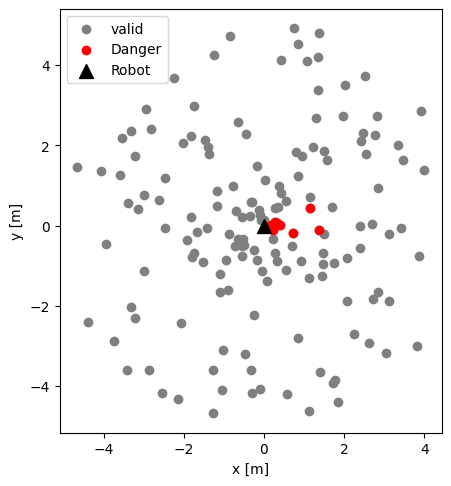

In [72]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
# TODO: ax.plot / ax.scatter 로 위 세 가지를 그리기

#유효 측정
ax.scatter(xy[:, 0], xy[:, 1], color ='gray', label = 'valid')
#위험 구간
ax.scatter(xy[danger, 0], xy[danger, 1], color ='red', label = 'Danger')
#로봇 위치
ax.scatter(0, 0, color = 'black', marker = '^', s=100, label = 'Robot')


ax.set_aspect('equal')
ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]')
ax.legend()
plt.show()

In [73]:
문항 6. 회전은 길이를 바꾸지 않는다
목표 — 점군 전체를 z축 45° 회전시키고, 원점까지의 거리가 보존되는지 확인한다.

주어진 것

xy — (N, 2) 점군
구현할 것

R — 2×2 회전행렬 (45°)
xy_rot — 회전된 (N, 2) 점군
기대 결과

회전 전후 거리 최대 차이 -> 0.0 (부동소수점 오차 수준)
힌트: 점이 행으로 쌓여 있으므로 xy @ R.T 입니다(6강 브로드캐스팅 절). R @ xy 는 shape 가 맞지 않습니다.

SyntaxError: invalid character '—' (U+2014) (1231292597.py, line 2)

In [74]:
th = np.radians(45)
c, s = np.cos(th), np.sin(th)
R  = np.array([
    [c, -s],
    [s, c] # TODO: 2x2 회전행렬
])

xy_rot = xy @ R  # TODO: (N, 2)

d0 = np.linalg.norm(xy, axis=1)
d1 = np.linalg.norm(xy_rot, axis=1)
print('거리 최대 차이:', np.abs(d0 - d1).max())

거리 최대 차이: 8.881784197001252e-16


In [75]:
# ── 자가 채점 (이 셀은 수정하지 마세요) ──
_c, _s = np.cos(np.radians(45)), np.sin(np.radians(45))
_R = np.array([[_c, -_s], [_s, _c]])
grade(6,
      check('R 이 2x2', np.shape(R) == (2, 2)),
      check('R 이 45도 회전행렬', np.allclose(R, _R),
            '[[cos, -sin], [sin, cos]] 순서를 확인하세요'),
      check('xy_rot 의 shape 가 유지됨', np.shape(xy_rot) == np.shape(xy)),
      check('회전이 길이를 보존', np.allclose(d0, d1),
            '길이가 변했다면 곱하는 순서나 전치를 확인하세요'))

  PASS  R 이 2x2
  PASS  R 이 45도 회전행렬
  PASS  xy_rot 의 shape 가 유지됨
  PASS  회전이 길이를 보존
[문항 6] 통과
